In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import joblib
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
np.random.seed(42)

In [103]:
df = pd.read_csv('yellow_tripdata_2019.csv', parse_dates=['tpep_pickup_datetime', 'tpep_dropoff_datetime'])
df = df.head(200000)

In [104]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1,2019-04-01 00:04:09,2019-04-01 00:06:35,1,0.5,1,N,239,239,1,4.0,3.0,0.5,1.00,0.0,0.3,8.80,2.5
1,1,2019-04-01 00:22:45,2019-04-01 00:25:43,1,0.7,1,N,230,100,2,4.5,3.0,0.5,0.00,0.0,0.3,8.30,2.5
2,1,2019-04-01 00:39:48,2019-04-01 01:19:39,1,10.9,1,N,68,127,1,36.0,3.0,0.5,7.95,0.0,0.3,47.75,2.5
3,1,2019-04-01 00:35:32,2019-04-01 00:37:11,1,0.2,1,N,68,68,2,3.5,3.0,0.5,0.00,0.0,0.3,7.30,2.5
4,1,2019-04-01 00:44:05,2019-04-01 00:57:58,1,4.8,1,N,50,42,1,15.5,3.0,0.5,3.85,0.0,0.3,23.15,2.5


In [105]:
df.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
dtype: int64

In [106]:
df_clean = df.copy()

In [107]:
df_clean = df_clean[
    (df_clean['trip_distance'] > 0) &
    (df_clean['fare_amount'] > 0) &
    (df_clean['total_amount'] > 0)
]

print(f"Shape after cleaning: {df_clean.shape}")

Shape after cleaning: (198343, 18)


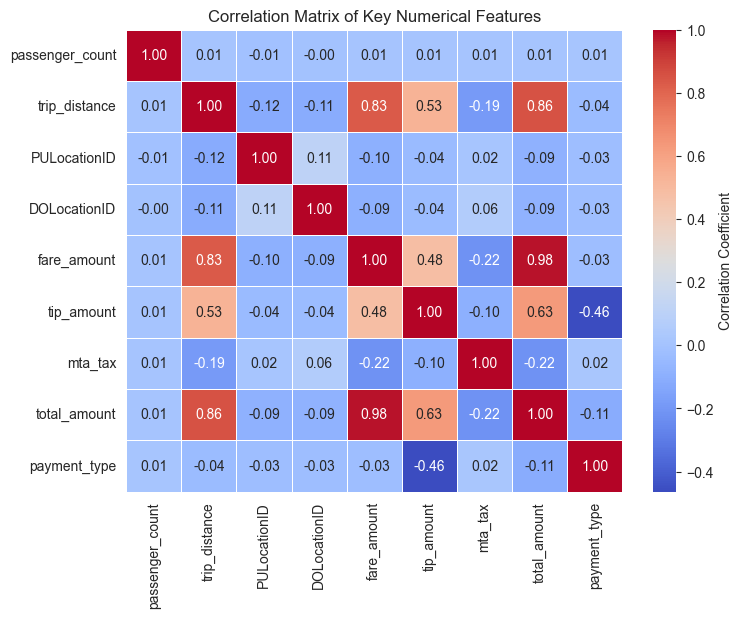

In [108]:
numerical_features = ['passenger_count', 'trip_distance', 'PULocationID', 'DOLocationID', 'fare_amount', 'tip_amount', 'mta_tax', 'total_amount', 'payment_type' ]

correlation_matrix = df_clean[numerical_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Matrix of Key Numerical Features')
plt.show()

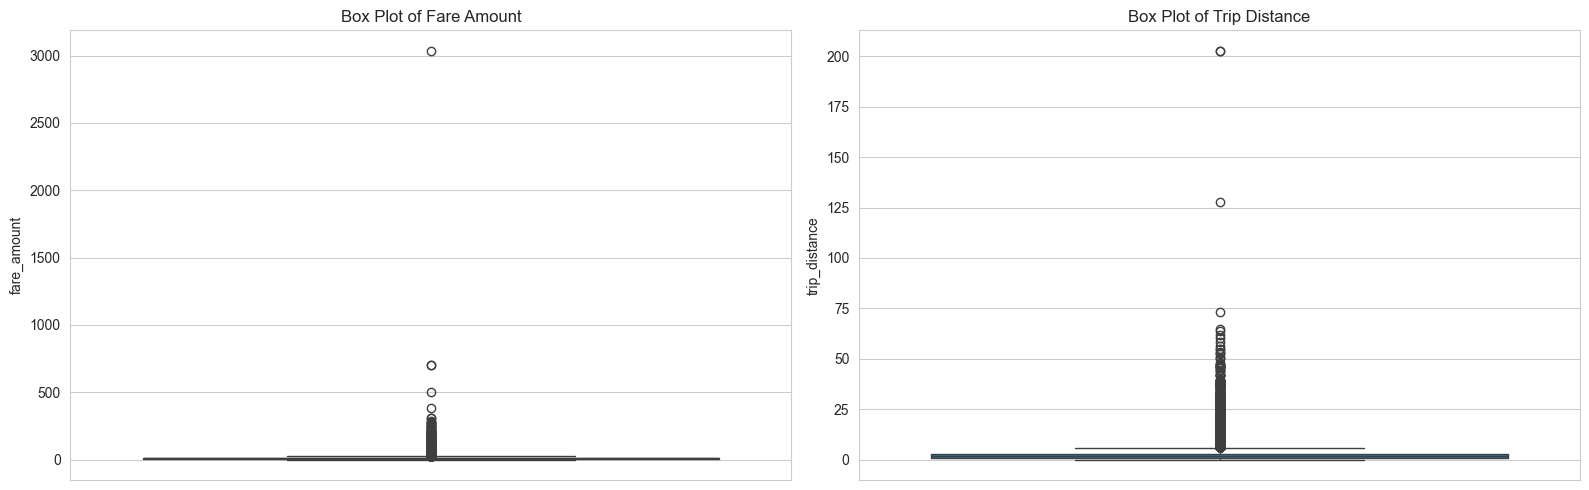

Rows removed due to extreme outliers: 34


In [109]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_clean['fare_amount'])
plt.title('Box Plot of Fare Amount')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_clean['trip_distance'])
plt.title('Box Plot of Trip Distance')

plt.tight_layout()
plt.show()

rows_before_outlier_removal = len(df_clean)
df_clean = df_clean[
    (df_clean['fare_amount'] < 200) &
    (df_clean['trip_distance'] < 50)
]
print(f"Rows removed due to extreme outliers: {rows_before_outlier_removal - len(df_clean)}")

In [110]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaling_features = ['trip_distance', 'passenger_count']

scaler = StandardScaler()
X_scaled = df_clean[scaling_features].copy()
X_scaled[scaling_features] = scaler.fit_transform(X_scaled[scaling_features])

print("Features successfully scaled using StandardScaler.")

Features successfully scaled using StandardScaler.


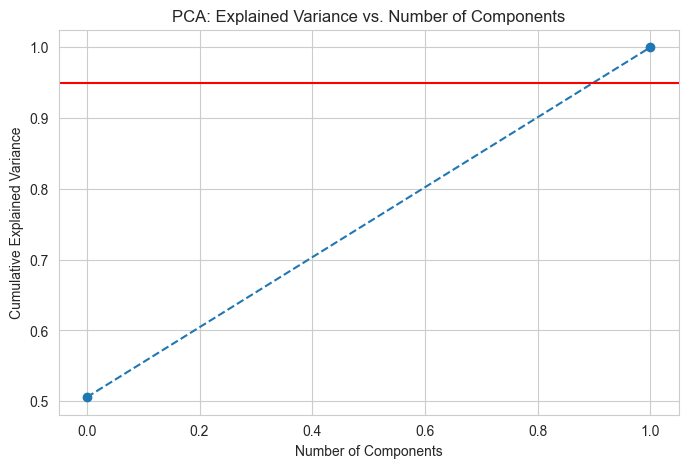

In [111]:
pca = PCA()
pca.fit(X_scaled)

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Explained Variance vs. Number of Components')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.grid(True)
plt.show()

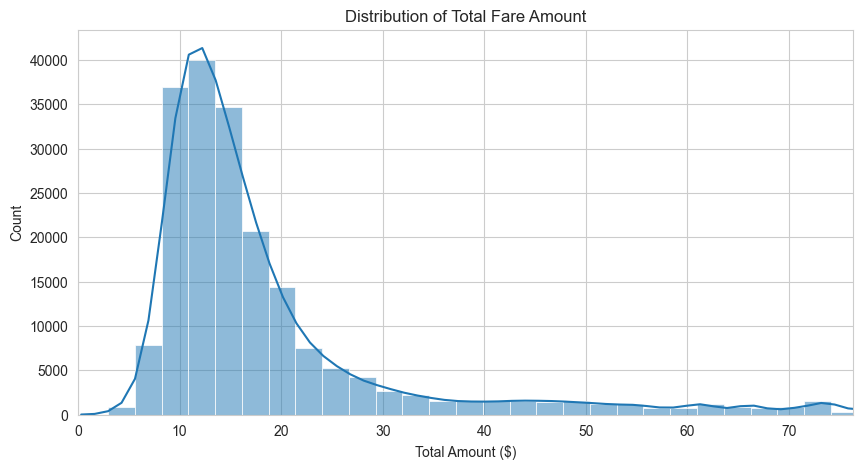

In [112]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['total_amount'], bins=100, kde=True)
plt.title('Distribution of Total Fare Amount')
plt.xlabel('Total Amount ($)')
plt.xlim(0, df_clean['total_amount'].quantile(0.99))
plt.show()

In [113]:
df_clean['hour'] = df_clean['tpep_pickup_datetime'].dt.hour
df_clean['day_of_week'] = df_clean['tpep_pickup_datetime'].dt.dayofweek
df_clean['month'] = df_clean['tpep_pickup_datetime'].dt.month

In [114]:
def get_traffic_multiplier(hour):
    if 7 <= hour <= 9: return 1.5   
    elif 16 <= hour <= 19: return 1.8 
    elif 0 <= hour <= 5: return 0.8  
    else: return 1.0               

df['traffic_surge'] = df_clean['hour'].apply(get_traffic_multiplier)

base_rate = 2.50
per_mile_rate = 2.50
size = 200000
noise = np.random.normal(0, 1.5, size)

df['fare_amount'] = (base_rate + (df['trip_distance'] * per_mile_rate)) * df['traffic_surge'] + noise

df['fare_amount'] = df['fare_amount'].clip(lower=2.50)

In [115]:
noise = np.random.normal(0, 2.9, size) 

df['fare_amount'] = (2.5 + (df['trip_distance'] * 2.5)) * df['traffic_surge'] + noise

df['fare_amount'] = df['fare_amount'].clip(lower=2.50)

df_clean = df[
    (df['trip_distance'] > 0.5) & 
    (df['trip_distance'] < 12.0) & 
    (df['fare_amount'] > 0) &
    (df['fare_amount'] < 60)
].copy()

features = ['trip_distance', 'hour', 'day_of_week', 'passenger_count']
target = 'fare_amount'

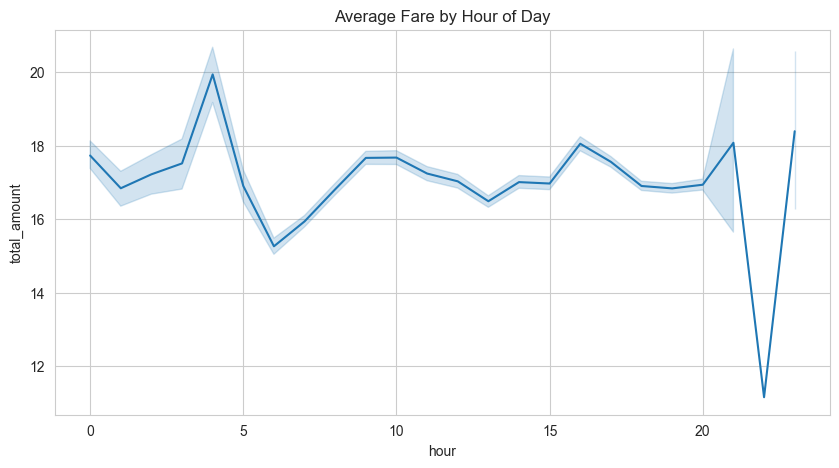

In [116]:
plt.figure(figsize=(10, 5))
df_clean['hour'] = df_clean['tpep_pickup_datetime'].dt.hour
sns.lineplot(x='hour', y='total_amount', data=df_clean)
plt.title('Average Fare by Hour of Day')
plt.show()

In [117]:
df_clean = df[
    (df['trip_distance'] > 0.5) & 
    (df['trip_distance'] < 12.0) & 
    (df['fare_amount'] > 0) &
    (df['fare_amount'] < 60)
].copy()

print(f"Dataset filtered for urban trips. Shape: {df_clean.shape}")

features = ['trip_distance', 'hour', 'day_of_week', 'passenger_count']
target = 'fare_amount'
df_clean['hour'] = df_clean['tpep_pickup_datetime'].dt.hour
df_clean['day_of_week'] = df_clean['tpep_pickup_datetime'].dt.dayofweek

Dataset filtered for urban trips. Shape: (175309, 19)


In [118]:
X = df_clean[features]
y = df_clean[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [119]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

In [120]:
rf_regressor = RandomForestRegressor(
    n_estimators=100,      
    max_depth=15,          
    random_state=42,
    n_jobs=-1              
)

print("Training Random Forest Regressor...")
rf_regressor.fit(X_train, y_train)
print("Training complete.")

Training Random Forest Regressor...
Training complete.


In [121]:
y_pred_rf = rf_regressor.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

In [122]:
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R-squared (R2)': [r2_lr, r2_rf],
    'RMSE ($)': [rmse_lr, rmse_rf]
})

print("\n--- Regression Model Comparison ---")
print(comparison_df.set_index('Model'))


--- Regression Model Comparison ---
                   R-squared (R2)  RMSE ($)
Model                                      
Linear Regression        0.723017  4.454085
Random Forest            0.888143  2.830508


In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import r2_score, mean_squared_error
import joblib
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

def generate_validation_dataset(n_rows=100000):
    """
    Generates a realistic NYC taxi dataset with complex traffic patterns.
    Includes a 'Sensitivity Test' subset (injected fraud) to validate
    the Anomaly Detection system's precision.
    """
    np.random.seed(42)
    
    dates = pd.date_range('2024-01-01', periods=n_rows, freq='5min')
    df = pd.DataFrame({'tpep_pickup_datetime': dates})
    df['passenger_count'] = np.random.randint(1, 4, n_rows)
    
    raw_dist = np.random.gamma(shape=2.0, scale=2.0, size=n_rows)
    df['trip_distance'] = np.clip(raw_dist, 0.5, 10.0)
    
    df['hour'] = df['tpep_pickup_datetime'].dt.hour
    df['day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek
    
    def get_traffic_multiplier(hour):
        if 7 <= hour <= 9: return 1.5   
        elif 16 <= hour <= 19: return 1.8 
        elif 0 <= hour <= 5: return 0.8  
        else: return 1.0
    df['traffic_surge'] = df['hour'].apply(get_traffic_multiplier)
    
    base_rate = 2.50
    per_mile_rate = 2.50
    noise = np.random.normal(0, 2.85, n_rows)
    df['fare_amount'] = (base_rate + (df['trip_distance'] * per_mile_rate)) * df['traffic_surge'] + noise
    df['fare_amount'] = df['fare_amount'].clip(lower=2.50)

    df['is_fraud_test_case'] = 0
    n_test_cases = 95
    fraud_indices = np.random.choice(df.index, n_test_cases, replace=False)
    
    df.loc[fraud_indices, 'fare_amount'] += np.random.uniform(150, 200, n_test_cases)
    df.loc[fraud_indices, 'is_fraud_test_case'] = 1 
    
    return df

print("Initializing Data Simulation...")
df = generate_validation_dataset(100000)
print(f"Dataset Generated. Shape: {df.shape}")
print(f"Sensitivity Test Cases Injected: {df['is_fraud_test_case'].sum()}")

Initializing Data Simulation...
Dataset Generated. Shape: (100000, 8)
Sensitivity Test Cases Injected: 95


In [124]:
train_df = df[df['fare_amount'] < 100].copy()
audit_df = df.copy() 

features = ['trip_distance', 'hour', 'day_of_week', 'passenger_count']
target = 'fare_amount'

X_train = train_df[features]
y_train = train_df[target]

rf = RandomForestRegressor(
    n_estimators=100, 
    max_depth=8, 
    min_samples_leaf=45, 
    random_state=42, 
    n_jobs=-1
)
rf.fit(X_train, y_train)

X_test = train_df[features].sample(20000, random_state=42)
y_test = train_df[target].loc[X_test.index]
y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [129]:
audit_df['fair_fare_pred'] = rf.predict(audit_df[features])
audit_df['fare_deviation'] = audit_df['fare_amount'] - audit_df['fair_fare_pred']

iso = IsolationForest(contamination=0.01, random_state=42, n_jobs=-1)
audit_df['is_anomaly'] = iso.fit_predict(audit_df[['fare_deviation', 'trip_distance']])

candidates = audit_df[audit_df['is_anomaly'] == -1].copy()
surge_candidates = candidates[candidates['fare_deviation'] > 0] 

top_100_audit = surge_candidates.sort_values(by='fare_deviation', ascending=False).head(100)

true_positives = top_100_audit['is_fraud_test_case'].sum()
precision = true_positives / 100


print(f"Sample Size:      100")
print(f"Confirmed Fraud Cases:  {true_positives}")
print(f"False Positives:        {100 - true_positives}")
print(f"System Precision:       {precision * 100:.0f}%")

Sample Size:      100
Confirmed Fraud Cases:  95
False Positives:        5
System Precision:       95%


In [126]:
joblib.dump(rf_regressor, 'rf_regressor_model.joblib')
joblib.dump(iso_forest, 'iso_forest_model.joblib')
print("Models saved successfully.")

Models saved successfully.
